In [4]:
!pip install scikit-learn
!pip install imbalanced-learn
!pip install category-encoders

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------------------- ------- 6.6/8.0 MB 36.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 32.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Bárbara Ramos\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Bárbara Ramos\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------------------------- ------------ 6.6/9.5 MB 34.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 31.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Bárbara Ramos\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import category_encoders as ce
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [61]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [3]:
df = pd.read_csv('employee-attrition.csv', index_col=0)
df.columns = df.columns.str.strip().str.lower()
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head(7)

Dataset shape: (1470, 34)

First 5 rows:


,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,...,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
Age,,,,,,,,,,,,,,,,,,,,,
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2
32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,...,3,80,0,8,2,2,7,7,3,6
59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,...,1,80,3,12,3,2,1,0,0,0


In [ ]:
df['attrition'].value_counts()
# Dataset is very highly imabalanced

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [4]:
attrition_mask = df['attrition'] == 'Yes'
gender_mask = df['gender'] == 'Male'
df['attrition'] = attrition_mask.astype(int)
df['gender'] = gender_mask.astype(int)
df.head(7)
# print(df.isnull().sum())

,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeecount,employeenumber,environmentsatisfaction,...,relationshipsatisfaction,standardhours,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
Age,,,,,,,,,,,,,,,,,,,,,
41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2
32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,...,3,80,0,8,2,2,7,7,3,6
59,0,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,...,1,80,3,12,3,2,1,0,0,0


## Feature Engineering

In [5]:

df['time_in_role_ratio'] = df['yearsincurrentrole'] / (df['yearsatcompany'] + 1e-6)
df['time_with_manager_ratio'] = df['yearswithcurrmanager']/ (df['yearsatcompany'] + 1e-6)
df['promotion_recency'] = 1 / (df['yearssincelastpromotion'] + 1)
df['role_stagnation'] = df['yearsincurrentrole'] - df['yearssincelastpromotion']
df['mobility_gap'] = df['yearsatcompany'] - df['yearsincurrentrole']
df = df.drop(columns=['monthlyincome', 'performancerating', 'yearsincurrentrole', 'yearswithcurrmanager'])


In [7]:
df.dtypes
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop('attrition').tolist()
print(len(num_cols), len(cat_cols))
print(num_cols)

27 7
['dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'gender', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearssincelastpromotion', 'time_in_role_ratio', 'time_with_manager_ratio', 'promotion_recency', 'role_stagnation', 'mobility_gap']


In [8]:

x = df[cat_cols + num_cols]
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33,random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution: {np.bincount(y_test)}")

Training set: (984, 34)
Test set: (486, 34)
Train class distribution: [825 159]
Test class distribution: [408  78]


In [13]:
ohe = ce.OneHotEncoder(cols=cat_cols)
X_train_encoded = ohe.fit_transform(X_train)
X_test_encoded = ohe.transform(X_test)

print(f"After encoding - Training set: {X_train_encoded.shape}")
print(f"After encoding - Test set: {X_test_encoded.shape}")
print(f"New feature columns: {list(X_train_encoded.columns)}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Scaled features mean: {X_train_scaled.mean():.6f}")
print(f"Scaled features std: {X_train_scaled.std():.6f}")

After encoding - Training set: (984, 54)
After encoding - Test set: (486, 54)
New feature columns: ['businesstravel_1', 'businesstravel_2', 'businesstravel_3', 'department_1', 'department_2', 'department_3', 'educationfield_1', 'educationfield_2', 'educationfield_3', 'educationfield_4', 'educationfield_5', 'educationfield_6', 'jobrole_1', 'jobrole_2', 'jobrole_3', 'jobrole_4', 'jobrole_5', 'jobrole_6', 'jobrole_7', 'jobrole_8', 'jobrole_9', 'maritalstatus_1', 'maritalstatus_2', 'maritalstatus_3', 'over18_1', 'overtime_1', 'overtime_2', 'dailyrate', 'distancefromhome', 'education', 'employeecount', 'employeenumber', 'environmentsatisfaction', 'gender', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'monthlyrate', 'numcompaniesworked', 'percentsalaryhike', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearssincelastpromotion', 'time_in_role_ratio', 'time_with_manager_rat

In [39]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
X_train_encoded_resampled, y_train_encoded_resampled = smote.fit_resample(X_train_encoded, y_train)


In [16]:
def CMDisplay(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(values_format="d")
    plt.show()
    print(classification_report(y_test, y_pred, labels=[0,1], target_names=["attrition_no(0)","attrition_yes(1)"], zero_division=0))

In [17]:
def compute_pr_auc(model, X, y_test):
    y_score = model.predict_proba(X)[:, 1]
    roc_auc= roc_auc_score(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    prec, rec, _ = precision_recall_curve(y_test, y_score)

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve (AP={ap:.3f})")
    plt.show()


    return roc_auc



def get_scores(estimator, X):
    """Return continuous scores for PR curve."""
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    raise ValueError("Estimator has neither predict_proba nor decision_function.")

def plot_pr_curves(models, y_test, title, baseline_line=True):
    """
    models: dict of {name: (estimator, X_test_for_that_estimator)}
    """
    plt.figure(figsize=(9, 6))

    if baseline_line:
        pos_rate = y_test.mean()
        plt.axhline(pos_rate, linestyle="--", linewidth=1, label=f"Baseline (pos rate={pos_rate:.3f})")

    for name, (est, X_used) in models.items():
        y_score = get_scores(est, X_used)
        ap = average_precision_score(y_test, y_score)
        prec, rec, _ = precision_recall_curve(y_test, y_score)
        plt.plot(rec, prec, linewidth=2, label=f"{name} (AP={ap:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True, alpha=0.2)
    plt.show()

## Simple Logistic Regression

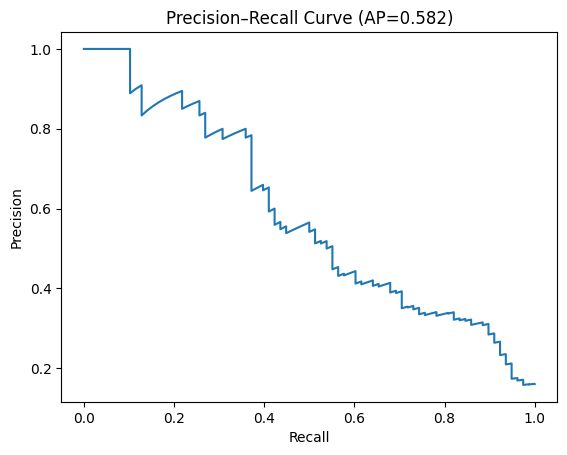

Logistic Regression Baseline : Accuracy: 0.7901 | Recall: 0.6795 | Precision: 0.4077 | F1 Score: 0.5096 | ROC_AUC score: 0.8233
[[331  77]
 [ 25  53]]


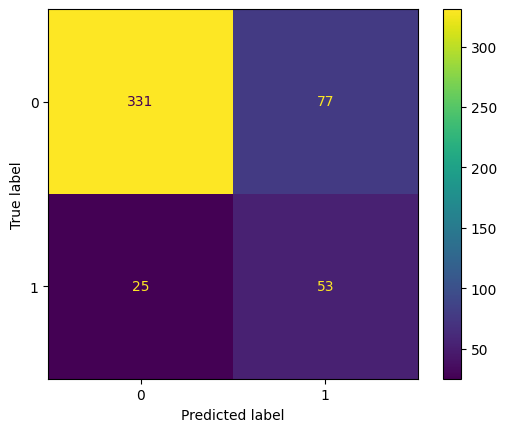

                  precision    recall  f1-score   support

 attrition_no(0)       0.93      0.81      0.87       408
attrition_yes(1)       0.41      0.68      0.51        78

        accuracy                           0.79       486
       macro avg       0.67      0.75      0.69       486
    weighted avg       0.85      0.79      0.81       486



In [ ]:

lr_baseline = LogisticRegression(random_state=42)
lr_baseline.fit(X_train_resampled, y_train_resampled)

y_pred_lr = lr_baseline.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
f1_score_lr = f1_score(y_test, y_pred_lr)

roc_auc_score_lr = compute_pr_auc(lr_baseline, X_test_scaled, y_test)

print(f"Logistic Regression Baseline : Accuracy: {accuracy_lr:.4f} | Recall: {rec_lr:.4f} | Precision: {prec_lr:.4f} | F1 Score: {f1_score_lr:.4f} | ROC_AUC score: {roc_auc_score_lr:.4f}")
CMDisplay(y_test, y_pred_lr)

## KNN Model

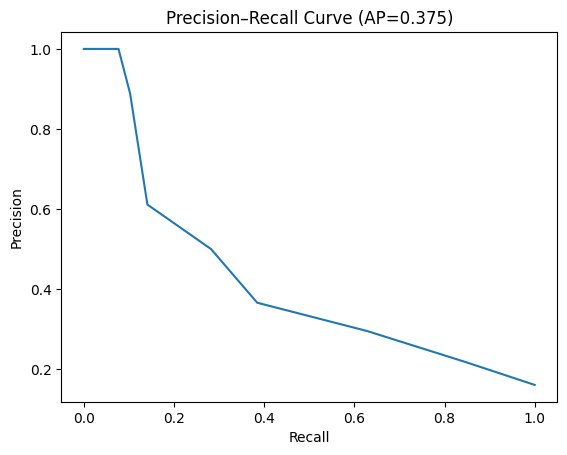

KNN Baseline : Accuracy: 0.8539 | Recall: 0.1026 | Precision: 0.8889 | F1 Score: 0.1839 | ROC_AUC score: 0.7187
[[407   1]
 [ 70   8]]


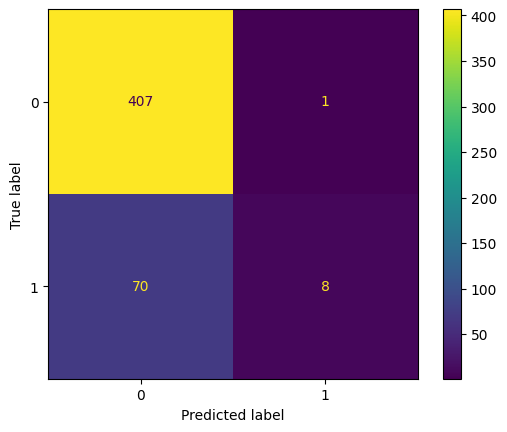

                  precision    recall  f1-score   support

 attrition_no(0)       0.85      1.00      0.92       408
attrition_yes(1)       0.89      0.10      0.18        78

        accuracy                           0.85       486
       macro avg       0.87      0.55      0.55       486
    weighted avg       0.86      0.85      0.80       486



In [26]:
k=10
knn_baseline = KNeighborsClassifier(n_neighbors=k, 
                                    p=1)
knn_baseline.fit(X_train_scaled, y_train)


y_pred_knn = knn_baseline.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
f1_score_knn = f1_score(y_test, y_pred_knn)

roc_auc_score_knn = compute_pr_auc(knn_baseline, X_test_scaled, y_test)
print(f"KNN Baseline : Accuracy: {accuracy_knn:.4f} | Recall: {rec_knn:.4f} | Precision: {prec_knn:.4f} | F1 Score: {f1_score_knn:.4f} | ROC_AUC score: {roc_auc_score_knn:.4f}")
CMDisplay(y_test, y_pred_knn)

#piorou

## Decision Trees

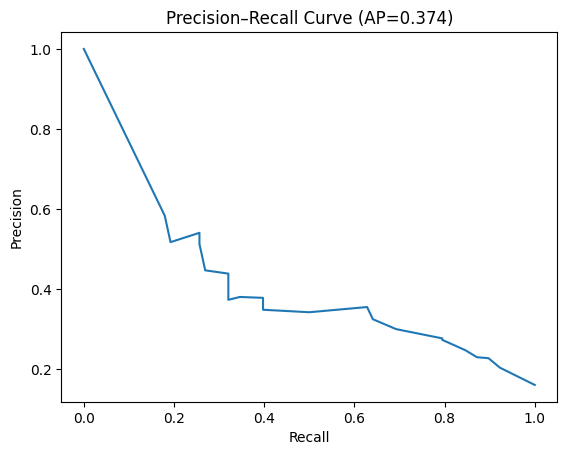

Decision Tree Baseline : Accuracy: 0.80453 | Recall: 0.3462 | Precision: 0.3803 | F1 Score: 0.3624 | ROC_AUC score: 0.7533
[[364  44]
 [ 51  27]]


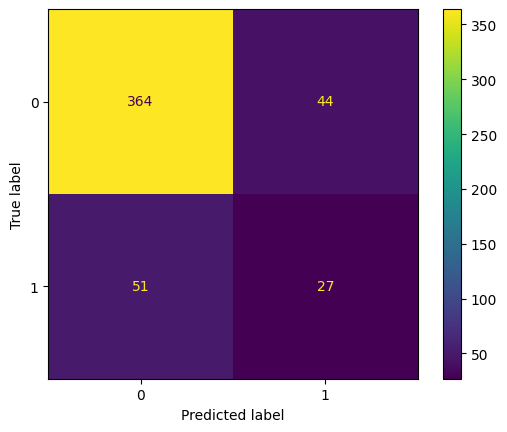

                  precision    recall  f1-score   support

 attrition_no(0)       0.88      0.89      0.88       408
attrition_yes(1)       0.38      0.35      0.36        78

        accuracy                           0.80       486
       macro avg       0.63      0.62      0.62       486
    weighted avg       0.80      0.80      0.80       486



In [42]:

# dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline = dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    ccp_alpha=0.001,   
    random_state=42,
)
dt_baseline.fit(X_train_encoded_resampled, y_train_encoded_resampled)


y_pred_dt = dt_baseline.predict(X_test_encoded)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
f1_score_dt = f1_score(y_test, y_pred_dt)
roc_auc_score_dt = compute_pr_auc(dt_baseline, X_test_encoded, y_test)

print(f"Decision Tree Baseline : Accuracy: {accuracy_dt:.5f} | Recall: {rec_dt:.4f} | Precision: {prec_dt:.4f} | F1 Score: {f1_score_dt:.4f} | ROC_AUC score: {roc_auc_score_dt:.4f}")
CMDisplay(y_test, y_pred_dt)


## Random Forest

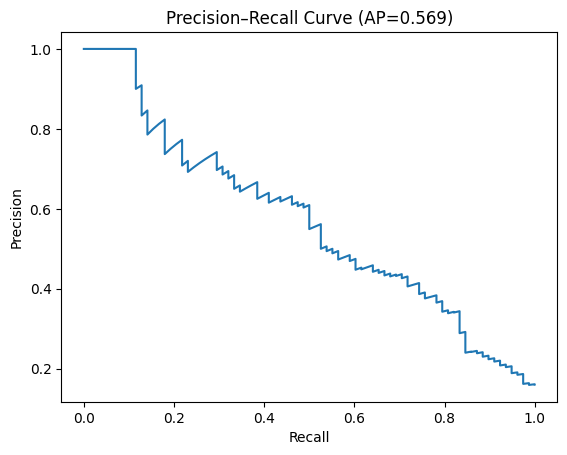

Random Forest : Accuracy: 0.8663 | Recall: 0.3462 | Precision: 0.6585 | F1 Score: 0.4538 | ROC_AUC score: 0.8196
[[394  14]
 [ 51  27]]


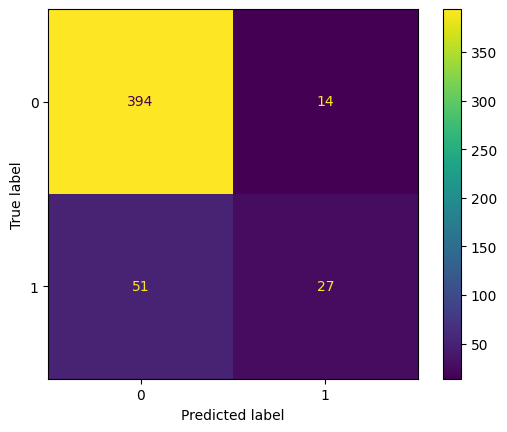

                  precision    recall  f1-score   support

 attrition_no(0)       0.89      0.97      0.92       408
attrition_yes(1)       0.66      0.35      0.45        78

        accuracy                           0.87       486
       macro avg       0.77      0.66      0.69       486
    weighted avg       0.85      0.87      0.85       486



In [40]:
# rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_encoded_resampled, y_train_encoded_resampled)

y_pred_rf = rf_baseline.predict(X_test_encoded)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
f1_score_rf = f1_score(y_test, y_pred_rf)


roc_auc_score_rf = compute_pr_auc(rf_baseline, X_test_encoded, y_test)
print(f"Random Forest : Accuracy: {accuracy_rf:.4f} | Recall: {rec_rf:.4f} | Precision: {prec_rf:.4f} | F1 Score: {f1_score_rf:.4f} | ROC_AUC score: {roc_auc_score_rf:.4f}")
CMDisplay(y_test, y_pred_rf)

## SVM

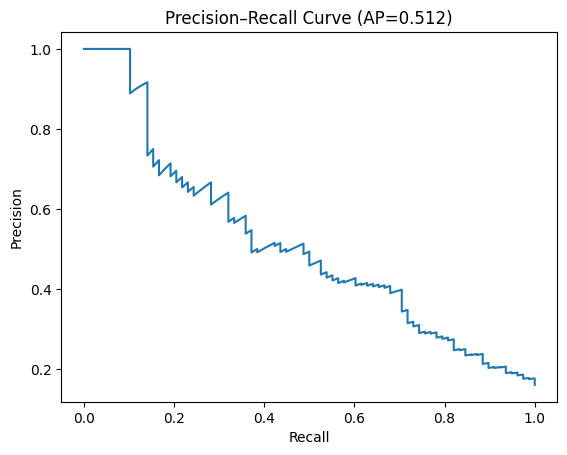

SVM Baseline : Accuracy: 0.8416 | Recall: 0.4103 | Precision: 0.5079 | F1 Score: 0.4539 | ROC_AUC score: 0.7895
[[377  31]
 [ 46  32]]


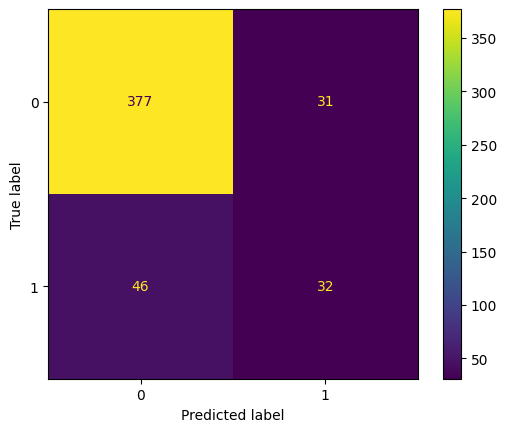

                  precision    recall  f1-score   support

 attrition_no(0)       0.89      0.92      0.91       408
attrition_yes(1)       0.51      0.41      0.45        78

        accuracy                           0.84       486
       macro avg       0.70      0.67      0.68       486
    weighted avg       0.83      0.84      0.83       486



In [37]:
# svm_baseline = SVC()
svm_baseline = SVC(
    kernel="rbf",
    C=1.0,               
    gamma="scale",
    probability=True,    
    random_state=42
)
svm_baseline.fit(X_train_resampled, y_train_resampled)

y_pred_svm = svm_baseline.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
f1_score_svm = f1_score(y_test, y_pred_svm)

roc_auc_score_svm = compute_pr_auc(svm_baseline, X_test_scaled, y_test)
print(f"SVM Baseline : Accuracy: {accuracy_svm:.4f} | Recall: {rec_svm:.4f} | Precision: {prec_svm:.4f} | F1 Score: {f1_score_svm:.4f} | ROC_AUC score: {roc_auc_score_svm:.4f}")
CMDisplay(y_test, y_pred_svm)

## PR_AUC Curves

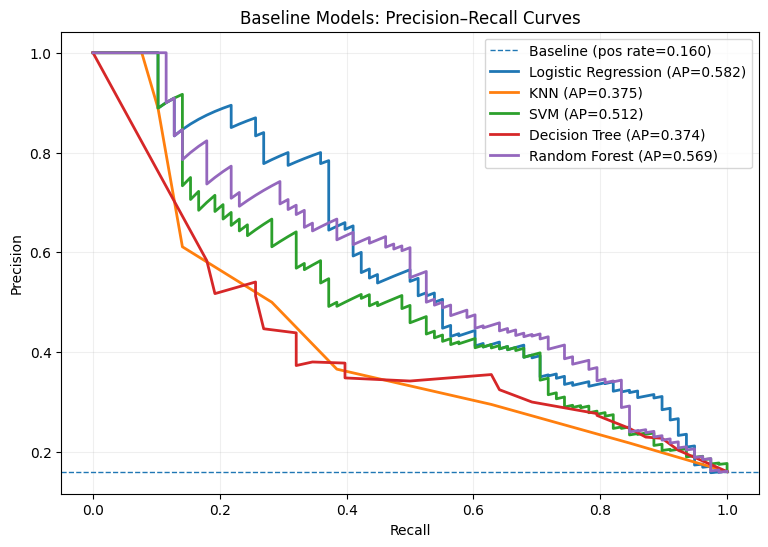

In [43]:
baseline_models = {
    "Logistic Regression": (lr_baseline, X_test_scaled),
    "KNN": (knn_baseline, X_test_scaled),
    "SVM": (svm_baseline, X_test_scaled),
    "Decision Tree": (dt_baseline, X_test_encoded),
    "Random Forest": (rf_baseline, X_test_encoded),
}

plot_pr_curves(baseline_models, y_test, "Baseline Models: Precision–Recall Curves")


## Compare all models

Baseline Model Comparison:


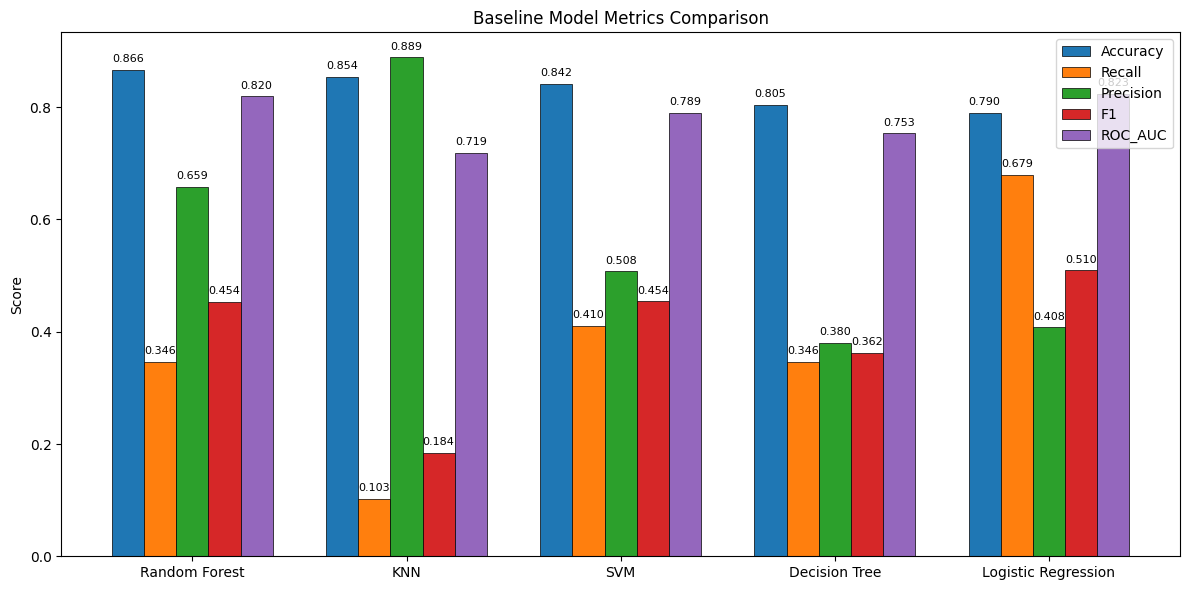

In [44]:
baseline_results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr, accuracy_knn, accuracy_dt, accuracy_rf, accuracy_svm],
    'Recall': [rec_lr, rec_knn, rec_dt, rec_rf, rec_svm],
    'Precision': [prec_lr, prec_knn, prec_dt, prec_rf, prec_svm],
    'F1': [f1_score_lr, f1_score_knn, f1_score_dt, f1_score_rf, f1_score_svm],
    'ROC_AUC': [roc_auc_score_lr, roc_auc_score_knn, roc_auc_score_dt, roc_auc_score_rf, roc_auc_score_svm]
}

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values('Accuracy', ascending=False)

print("Baseline Model Comparison:")

# Metrics you want to plot
metrics = ['Accuracy', 'Recall', 'Precision', 'F1', 'ROC_AUC']

# Number of models and metrics
n_models = len(baseline_df)
n_metrics = len(metrics)

# Set bar positions
x = np.arange(n_models)
width = 0.15  # width of each bar

# Create figure
plt.figure(figsize=(12, 6))

bars = []
# Plot each metric
for i, metric in enumerate(metrics):
    bar_group = plt.bar(
        x + i*width,
        baseline_df[metric],
        width,
        label=metric,
        edgecolor='black',       # ← border
        linewidth=0.5           # ← border thickness
    )
    bars.append(bar_group)

# Add value labels on top of each bar
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(x + width * (n_metrics/2 - 0.5), baseline_df['Model'])
plt.ylabel('Score')
plt.title('Baseline Model Metrics Comparison')
plt.legend()

plt.tight_layout()
plt.show()


In [62]:

preprocess_scaled = ColumnTransformer([
  ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
  ("num", StandardScaler(), num_cols),
])

preprocess_tree = ColumnTransformer([
  ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
  ("num", "passthrough", num_cols),
])

lr_est = ImbPipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

knn_est = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", KNeighborsClassifier())
])

svm_est = ImbPipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC( probability=False, random_state=42))
])

dt_est = ImbPipeline(steps=[
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

rf_est = ImbPipeline(steps=[
    ("preprocess", preprocess_tree),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

## GRID SEARCH

In [63]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Logistic Regression parameters
lr_param_grid = [
    {"smote__k_neighbors": [3, 5],"model__solver": ["liblinear"], "model__penalty": ["l1", "l2"], "model__C": [0.1, 1, 10, 100]},
    {"smote__k_neighbors": [3, 5],"model__solver": ["lbfgs"],     "model__penalty": ["l2"],       "model__C": [0.1, 1, 10, 100]},
    {"smote__k_neighbors": [3, 5],"model__solver": ["saga"],      "model__penalty": ["l1", "l2"], "model__C": [0.1, 1, 10, 100]},
]

# KNN parameters
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'model__weights':['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
    
}

# SVM parameters
svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto'],
    'smote__k_neighbors': [3, 5]
}

# Decision Tree parameters
dt_param_grid = {
    'model__max_depth':  [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'smote__k_neighbors': [3, 5]
}

# Random Forest parameters
rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1,2,4],
    'model__max_features': ["sqrt","log2", None],
    'smote__k_neighbors': [3, 5]
}

# Print parameter grid sizes
param_grids = {
    'Logistic Regression': lr_param_grid,
    'KNN': knn_param_grid,
    'SVM': svm_param_grid,
    'Decision Tree': dt_param_grid,
    'Random Forest': rf_param_grid
}

# for model_name, param_grid in param_grids.items():
#     total_combinations = 1
#     for values in param_grid.values():
#         total_combinations *= len(values)
#     print(f"{model_name}: {total_combinations} parameter combinations")

In [64]:

models = {
    'Logistic Regression': (lr_baseline, lr_param_grid, X_train_resampled),
    'KNN': (knn_baseline, knn_param_grid, X_train_scaled),
    'SVM': (svm_baseline, svm_param_grid, X_train_resampled),
    'Decision Tree': (dt_baseline, dt_param_grid, X_train_encoded_resampled),
    'Random Forest': (rf_baseline, rf_param_grid, X_train_encoded_resampled)
}

# Store results
grid_search_results = {}

scoring_metric = 'average_precision' #to be decided



## LR Grid

In [65]:
lr_model, lr_grid, lr_data = models['Logistic Regression']

lr_grid_search = GridSearchCV(
    estimator=lr_est,
    param_grid=lr_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1, 
    verbose=1  
)

lr_grid_search.fit(X_train, y_train)

grid_search_results['Logistic Regression'] = lr_grid_search
print(f"✅ Best params: {lr_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {lr_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
✅ Best params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear', 'smote__k_neighbors': 3}
✅ Best CV average_precision: 0.6406



C:\Users\Bárbara Ramos\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## KNN Grid

In [71]:


knn_grid_search = GridSearchCV(
    estimator=knn_est,
    param_grid=knn_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,
    verbose=1
)

knn_grid_search.fit(X_train, y_train)

grid_search_results['KNN'] = knn_grid_search
print(f"✅ Best params: {knn_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {knn_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
✅ Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 31, 'model__weights': 'distance'}
✅ Best CV average_precision: 0.5237



## Decision Trees Grid

In [66]:

dt_grid_search = GridSearchCV(
    estimator=dt_est,
    param_grid=dt_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,  
    verbose=1  
)

dt_grid_search.fit(X_train, y_train)


grid_search_results['Decision Tree'] = dt_grid_search
print(f"✅ Best params: {dt_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {dt_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 90 candidates, totalling 450 fits
✅ Best params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'smote__k_neighbors': 3}
✅ Best CV average_precision: 0.3481



## Random Forest Grid

In [67]:


rf_grid_search = GridSearchCV(
    estimator=rf_est,
    param_grid=rf_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,  
    verbose=1  
)

rf_grid_search.fit(X_train, y_train)


grid_search_results['Random Forest'] = rf_grid_search
print(f"✅ Best params: {rf_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {rf_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
✅ Best params: {'model__max_depth': 7, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100, 'smote__k_neighbors': 5}
✅ Best CV average_precision: 0.5744



## SVM Grid

In [68]:


svm_grid_search = GridSearchCV(
    estimator=svm_est,
    param_grid=svm_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,  
    verbose=1  
)

svm_grid_search.fit(X_train, y_train)


grid_search_results['SVM'] = svm_grid_search
print(f"✅ Best params: {svm_grid_search.best_params_}")
print(f"✅ Best CV {scoring_metric}: {svm_grid_search.best_score_:.4f}\n")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Best params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear', 'smote__k_neighbors': 3}
✅ Best CV average_precision: 0.6289




Final Model Comparison:
              Model  Best_CV_Score  Test_Accuracy  Test_Precision  Test_Avg_Precision  Test_Recall  Test_F1
Logistic Regression         0.6406         0.7942          0.8473              0.6020       0.7942   0.8125
                SVM         0.6289         0.7922          0.8444              0.5856       0.7922   0.8104
      Random Forest         0.5744         0.8642          0.8458              0.5560       0.8642   0.8425
                KNN         0.5237         0.8519          0.8552              0.4146       0.8519   0.7974
      Decision Tree         0.3481         0.8374          0.8417              0.3714       0.8374   0.8395


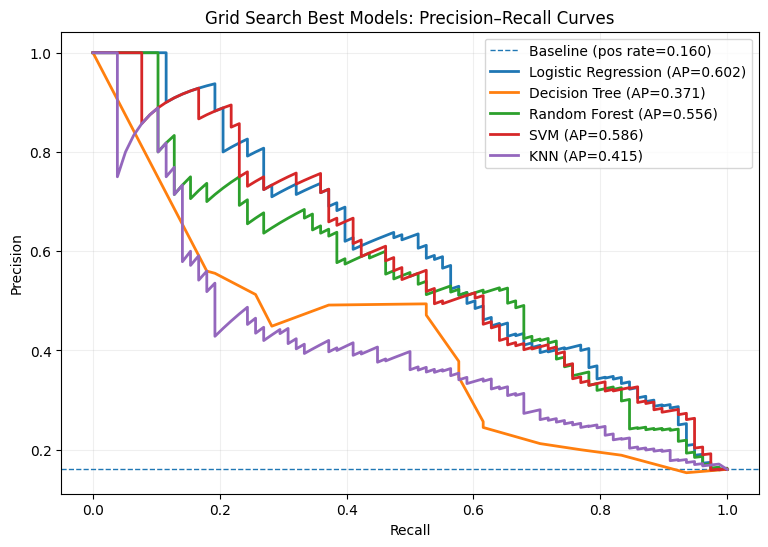

In [72]:
final_results = []

for model_name, grid_search in grid_search_results.items():
    # Get the best model
    best_model = grid_search.best_estimator_

    # Make predictions
    y_pred = best_model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0.0)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test)[:, 1]
    else:
        # e.g., SVM with probability=False
        y_score = best_model.decision_function(X_test)
    roc_auc= roc_auc_score(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    prec, rec, _ = precision_recall_curve(y_test, y_score)

    final_results.append({
        'Model': model_name,
        'Best_CV_Score': grid_search.best_score_,
        'Test_Accuracy': accuracy,
        'Test_Precision': precision,
        'Test_Avg_Precision': ap,
        'Test_Recall': recall,
        'Test_F1': f1
    })

    # print(f"{model_name}:")
    # print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    # print(f"  Test Accuracy: {accuracy:.4f}")
    # print(f"  Test F1-Score: {f1:.4f}")
    # print(f"  Test Recall-Score: {recall:.4f}")
    # print(f"  Test Precision-Score: {precision:.4f}")
    # print(f"  Test Avg-Precision-Score: {ap:.4f}")
    # print()

# Create results DataFrame
results_df = pd.DataFrame(final_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test_Avg_Precision', ascending=False)

print("\nFinal Model Comparison:")
print(results_df.to_string(index=False))

grid_best_models = {
    name: (gs.best_estimator_, X_test)   # raw X_test because pipeline handles preprocessing
    for name, gs in grid_search_results.items()
}

plot_pr_curves(grid_best_models, y_test, "Grid Search Best Models: Precision–Recall Curves")


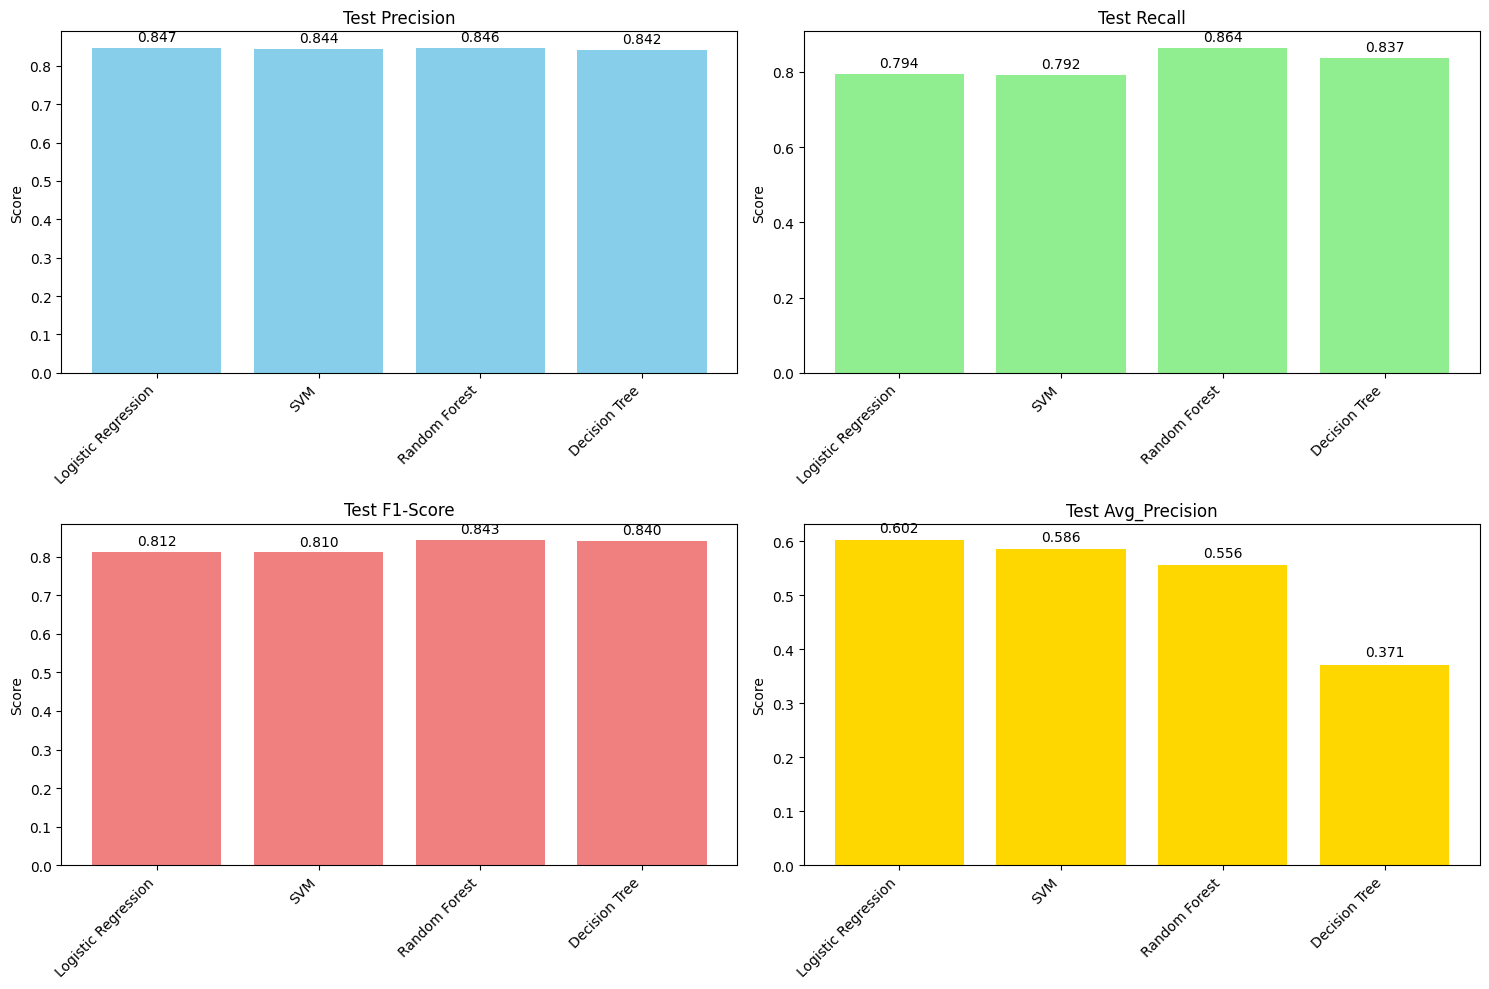

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [ 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_Avg_Precision']
titles = ['Test Precision', 'Test Recall', 'Test F1-Score', 'Test Avg_Precision']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold',]

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]

    bars = ax.bar(results_df['Model'], results_df[metric], color=color)
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelrotation=45)
    plt.setp(ax.get_xticklabels(), ha='right')


    
    for bar, value in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_grid_search = grid_search_results[best_model_name]
best_model = best_grid_search.best_estimator_

print(f"🏆 Best Model: {best_model_name}")
print(f"Best Parameters: {best_grid_search.best_params_}")
print(f"Test Accuracy: {results_df.iloc[0]['Test_Avg_Precision']:.4f}")
print()

# Choose appropriate test data
# if best_model_name in ['Logistic Regression', 'KNN', 'SVM']:
#     X_test_best = X_test_scaled
# else:
#     X_test_best = X_test_encoded

y_pred_best = best_model.predict(X_test)

# Detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['0', '1'], zero_division=0.0))

🏆 Best Model: Logistic Regression
Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'saga'}
Test Accuracy: 0.6215

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       408
           1       0.41      0.74      0.52        78

    accuracy                           0.78       486
   macro avg       0.67      0.77      0.69       486
weighted avg       0.86      0.78      0.81       486



<Figure size 800x600 with 0 Axes>

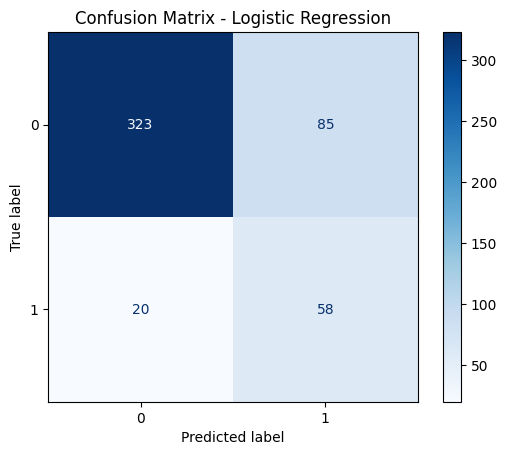

True Negatives (Correctly predicted 0): 323
False Positives (Incorrectly predicted 1): 85
False Negatives (Incorrectly predicted 0): 20
True Positives (Correctly predicted 1): 58


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# Calculate additional insights
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correctly predicted 0): {tn}")
print(f"False Positives (Incorrectly predicted 1): {fp}")
print(f"False Negatives (Incorrectly predicted 0): {fn}")
print(f"True Positives (Correctly predicted 1): {tp}")